In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
from PIL import Image
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import signal
import sys
import os

#----------------------------------------------------------------
# Версия с регрессией коэф. Чебышёва до 7 порядка. ResNet18 без предобучения.
#----------------------------------------------------------------
torch.manual_seed(0)

# Проверка доступности GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

datasetDirectory = './dataset'
# Загрузка метаданных
with open(datasetDirectory + '/metadata.json', 'r') as f:
    metadata = json.load(f)

print(f"Total samples: {len(metadata)}")



Using device: cuda
Total samples: 80000


In [ ]:
class ChebyshevDiffractionDataset(Dataset):
    def __init__(self, metadata, root_dir, indices=None, transform=None):
        self.metadata = metadata
        self.root_dir = root_dir
        self.transform = transform
        if indices is None:
            self.indices = list(range(len(metadata)))
        else:
            self.indices = indices


        all_keys = list(metadata[0]['chebyshev_coefficients'].keys())
        # Удаляем '0_0', если он есть
        if '0_0' in all_keys:
            all_keys.remove('0_0')
        def key_order(key):
            p, q = map(int, key.split('_'))
            return (p+q, p, q)
        self.cheb_keys = sorted(all_keys, key=key_order)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        item = self.metadata[self.indices[idx]]
        
        base_name = item['filename']  #  "beam_075084.png"
    
        img_path = os.path.join(self.root_dir, 'difracted_' + base_name) # difracted_beam_0824245
        
        if not os.path.exists(img_path):
            raise FileNotFoundError(f"File not found, check the name in /dataset/difracted_beams/")


        image = Image.open(img_path)
        if image.size != (256, 256):
            image = image.resize((256, 256), Image.LANCZOS)
        if self.transform:
            image = self.transform(image)

        coeffs = torch.zeros(len(self.cheb_keys), dtype=torch.float32)
        for i, key in enumerate(self.cheb_keys):
            coeffs[i] = item['chebyshev_coefficients'][key] / np.pi   # нормализация
        return image, coeffs

In [3]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    # Оставляем только изменение яркости/контраста – это не влияет на фазу
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

In [ ]:
""" Модель """

import torch.nn as nn
import torchvision.models as models

class ChebyshevRegressionModel(nn.Module):
    def __init__(self, num_coeffs=35, dropout = 0.3):
        super().__init__()
        # Используем необученный ResNet18 (можно протестить другие, но пока работает - пусть работает))
        self.backbone = models.resnet18(pretrained=False)
        # Заменяем последний слой на регрессионную голову
        # У ResNet18 выход признаков – 512
        self.backbone.fc = nn.Identity()   # убираем классификатор
        self.fc = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(512, num_coeffs))

    def forward(self, x):
        features = self.backbone(x)  # (batch, 512)
        return self.fc(features)



In [ ]:
#-----------------------------------------------------------------------------------------Функция потерь-----------------------------------------------------------------------------------------------------
class WeightedMSELoss(nn.Module):
    def __init__(self, weights=None):
        super().__init__()
        if weights is None:
            # По умолчанию все веса = 1
            weights = torch.ones(35, dtype=torch.float32)
        self.weights = weights.to(device)

    def forward(self, pred, target):
        return torch.mean(self.weights * (pred - target) ** 2)

In [6]:
# Разделение на train/validation/test-------------------------------------------------------------Инициализация датасета-----------------------------------------------------------
# Загрузка метаданных
with open(os.path.join(datasetDirectory, 'metadata.json'), 'r') as f:
    metadata = json.load(f)

total_count = len(metadata)
indices = list(range(total_count))

# Разбиение 70/15/15
train_size = int(0.7 * total_count)
val_size = int(0.15 * total_count)
test_size = total_count - train_size - val_size

train_idx, val_idx, test_idx = random_split(
    indices,
    [train_size, val_size, test_size]
)

# Создание датасетов
train_dataset = ChebyshevDiffractionDataset(
    metadata=metadata,
    root_dir=os.path.join(datasetDirectory, 'difracted_beams'),
    indices=train_idx,
    transform=train_transform
)

val_dataset = ChebyshevDiffractionDataset(
    metadata=metadata,
    root_dir=os.path.join(datasetDirectory, 'difracted_beams'),
    indices=val_idx,
    transform=val_transform
)

test_dataset = ChebyshevDiffractionDataset(
    metadata=metadata,
    root_dir=os.path.join(datasetDirectory, 'difracted_beams'),
    indices=test_idx,
    transform=val_transform
)

# DataLoader
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                        num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                         num_workers=0, pin_memory=True)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Train: 56000, Val: 12000, Test: 12000


In [7]:
model = ChebyshevRegressionModel(num_coeffs=35, dropout=0.3).to(device)

# Подсчёт параметров
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {count_parameters(model):,}")

# Функция потерь
criterion = WeightedMSELoss()

# Оптимизатор: можно разные LR для бэкбона и головы
optimizer = optim.AdamW([
    {'params': model.backbone.parameters(), 'lr': 1e-5},
    {'params': model.fc.parameters(), 'lr': 1e-4}
], weight_decay=1e-3)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                  factor=0.5, patience=7)

c:\Users\thatm\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\thatm\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Total trainable parameters: 11,194,467


In [8]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    for data, target in loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running_loss += loss.item()
    return running_loss / len(loader)

def validate_epoch(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            running_loss += loss.item()
    return running_loss / len(loader)

In [9]:
# Загрузка чекпоинта
model_name = 'chebyshev_model_1_5_1.pth'
train_losses = []
val_losses = []
best_val_loss = float('inf')
patience = 10
patience_counter = 0
start_epoch = 0

if os.path.exists(model_name):
    response = input("Found checkpoint! Load and continue training? (y/n): ")
    if response.lower() == 'y':
        checkpoint = torch.load(model_name)
        start_epoch = checkpoint['epoch'] + 1
        train_losses = checkpoint['train_losses']
        val_losses = checkpoint['val_losses']
        best_val_loss = checkpoint.get('best_val_loss', float('inf'))
        patience_counter = checkpoint.get('patience_counter', 0)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        print(f"Continuing from epoch {start_epoch}")
    else:
        print("Starting fresh training")

Continuing from epoch 111


In [11]:

num_epochs = 200

try:
    for epoch in range(start_epoch, num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        train_loss = train_epoch(model, train_loader, optimizer, criterion)
        val_loss = validate_epoch(model, val_loader, criterion)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        scheduler.step(val_loss)

        print(f'Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'train_losses': train_losses,
                'val_losses': val_losses,
                'best_val_loss': best_val_loss,
                'patience_counter': patience_counter,
            }, model_name)
            print('Best model saved!')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print('Early stopping!')
                break

except KeyboardInterrupt:
    print("Training interrupted")

print("Training completed!")


Epoch 112/200
Training interrupted
Training completed!


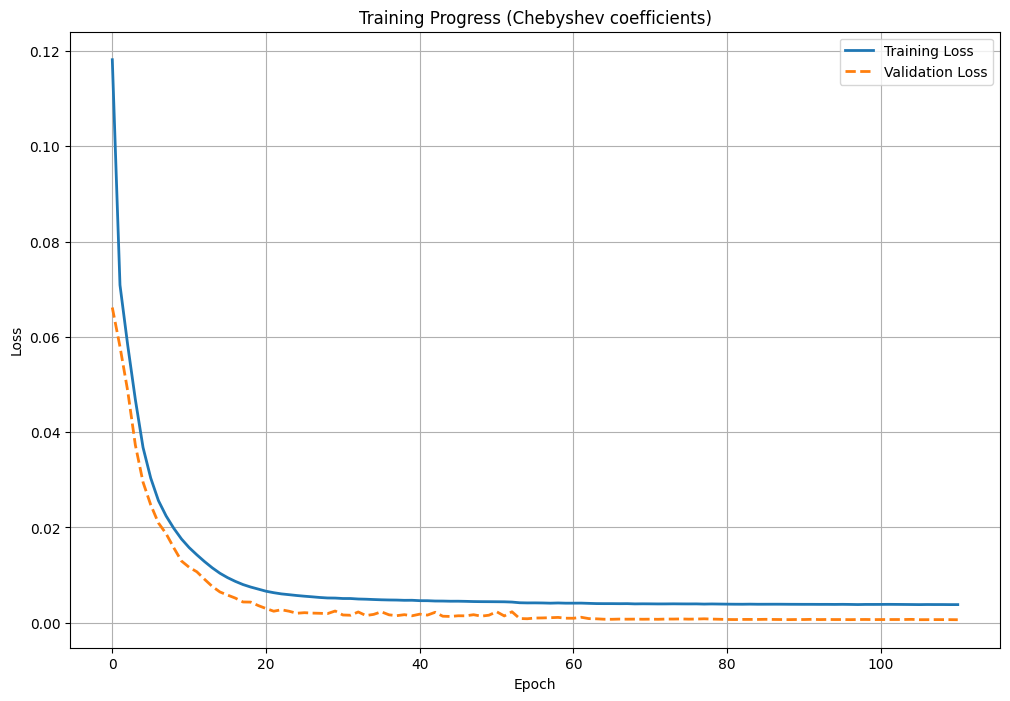

In [10]:
plt.figure(figsize=(12, 8))
plt.plot(train_losses, label='Training Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2, linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Progress (Chebyshev coefficients)')
plt.grid(True)
plt.savefig('training_chebyshev.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:

#model_name = 'chebyshev_model_1_5_1.pth'

# Загрузка модели
checkpoint = torch.load(model_name)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()

# Функция оценки
def evaluate_chebyshev_model(model, loader, cheb_keys):
    model.eval()
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for data, target in loader:
            data = data.to(device)
            predictions = model(data)
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(target.numpy())

    all_predictions = np.vstack(all_predictions)
    all_targets = np.vstack(all_targets)

    # Метрики (нормализованные, т.к. данные были поделены на π)
    mse_per_feature = np.mean((all_predictions - all_targets) ** 2, axis=0)
    mae_per_feature = np.mean(np.abs(all_predictions - all_targets), axis=0)
    r2_per_feature = 1 - np.sum((all_predictions - all_targets) ** 2, axis=0) / \
                     (np.sum((all_targets - np.mean(all_targets, axis=0)) ** 2, axis=0) + 1e-8)

    return mse_per_feature, mae_per_feature, r2_per_feature, all_predictions, all_targets

# Получаем ключи коэффициентов из датасета (или из первого элемента метаданных)
if hasattr(train_dataset, 'cheb_keys'):
    cheb_keys = train_dataset.cheb_keys
else:
    # fallback: из метаданных
    sample_keys = list(metadata[0]['chebyshev_coefficients'].keys())
    def key_order(key):
        p, q = map(int, key.split('_'))
        return (p+q, p, q)
    cheb_keys = sorted(sample_keys, key=key_order)

# Оценка на тестовом наборе
mse_norm, mae_norm, r2_norm, predictions, targets = evaluate_chebyshev_model(
    model, test_loader, cheb_keys
)

# Денормировка - умножаем на pi, так как при обучении делили на pi
mae_denorm = mae_norm * np.pi
mse_denorm = mse_norm * (np.pi ** 2)

# Вывод результатов (нормализованные метрики)
print("=== Model Evaluation on Test Set (Chebyshev coefficients) ===\n")
print("Normalized metrics (values divided by π):")
print("-" * 80)
print(f"{'Coeff key':<12} {'MAE (norm)':<12} {'MSE (norm)':<12} {'R²':<10}")
print("-" * 80)
for i, key in enumerate(cheb_keys):
    print(f"{key:<12} {mae_norm[i]:.6f}   {mse_norm[i]:.6f}   {r2_norm[i]:.6f}")
print("-" * 80)
print(f"{'Overall':<12} {mae_norm.mean():.6f}   {mse_norm.mean():.6f}   {r2_norm.mean():.6f}")

# Вывод результатов (денормированные, в радианах)
print("\nDenormalized metrics (coefficients in radians):")
print("-" * 80)
print(f"{'Coeff key':<12} {'MAE (rad)':<12} {'MSE (rad²)':<12} {'R²':<10}")
print("-" * 80)
for i, key in enumerate(cheb_keys):
    print(f"{key:<12} {mae_denorm[i]:.6f}   {mse_denorm[i]:.6f}   {r2_norm[i]:.6f}")
print("-" * 80)
print(f"{'Overall':<12} {mae_denorm.mean():.6f}   {mse_denorm.mean():.6f}   {r2_norm.mean():.6f}")

# Сохранение результатов в файл
result_filename = model_name.replace('.pth', '_evaluation.txt')
with open(result_filename, 'w', encoding='utf-8') as f:
    f.write("=== Chebyshev Model Evaluation ===\n\n")
    f.write("Normalized metrics (coefficients divided by π):\n")
    f.write("-" * 80 + "\n")
    f.write(f"{'Coeff key':<12} {'MAE (norm)':<12} {'MSE (norm)':<12} {'R²':<10}\n")
    f.write("-" * 80 + "\n")
    for i, key in enumerate(cheb_keys):
        f.write(f"{key:<12} {mae_norm[i]:.6f}   {mse_norm[i]:.6f}   {r2_norm[i]:.6f}\n")
    f.write("-" * 80 + "\n")
    f.write(f"{'Overall':<12} {mae_norm.mean():.6f}   {mse_norm.mean():.6f}   {r2_norm.mean():.6f}\n\n")

    f.write("Denormalized metrics (coefficients in radians):\n")
    f.write("-" * 80 + "\n")
    f.write(f"{'Coeff key':<12} {'MAE (rad)':<12} {'MSE (rad²)':<12} {'R²':<10}\n")
    f.write("-" * 80 + "\n")
    for i, key in enumerate(cheb_keys):
        f.write(f"{key:<12} {mae_denorm[i]:.6f}   {mse_denorm[i]:.6f}   {r2_norm[i]:.6f}\n")
    f.write("-" * 80 + "\n")
    f.write(f"{'Overall':<12} {mae_denorm.mean():.6f}   {mse_denorm.mean():.6f}   {r2_norm.mean():.6f}\n")

print(f"\nEvaluation results saved to {result_filename}")

=== Model Evaluation on Test Set (Chebyshev coefficients) ===

Normalized metrics (values divided by π):
--------------------------------------------------------------------------------
Coeff key    MAE (norm)   MSE (norm)   R²        
--------------------------------------------------------------------------------
0_1          0.028587   0.001323   0.996043
1_0          0.028326   0.001297   0.996144
0_2          0.019226   0.000600   0.998196
1_1          0.035837   0.002081   0.993826
2_0          0.019105   0.000588   0.998244
0_3          0.016168   0.000425   0.994866
1_2          0.027402   0.001235   0.985135
2_1          0.028348   0.001306   0.984264
3_0          0.016515   0.000436   0.994772
0_4          0.014561   0.000335   0.990917
1_3          0.022147   0.000789   0.978933
2_2          0.023788   0.000906   0.975533
3_1          0.023103   0.000860   0.976711
4_0          0.016043   0.000405   0.988985
0_5          0.014789   0.000342   0.983553
1_4          0.020114  

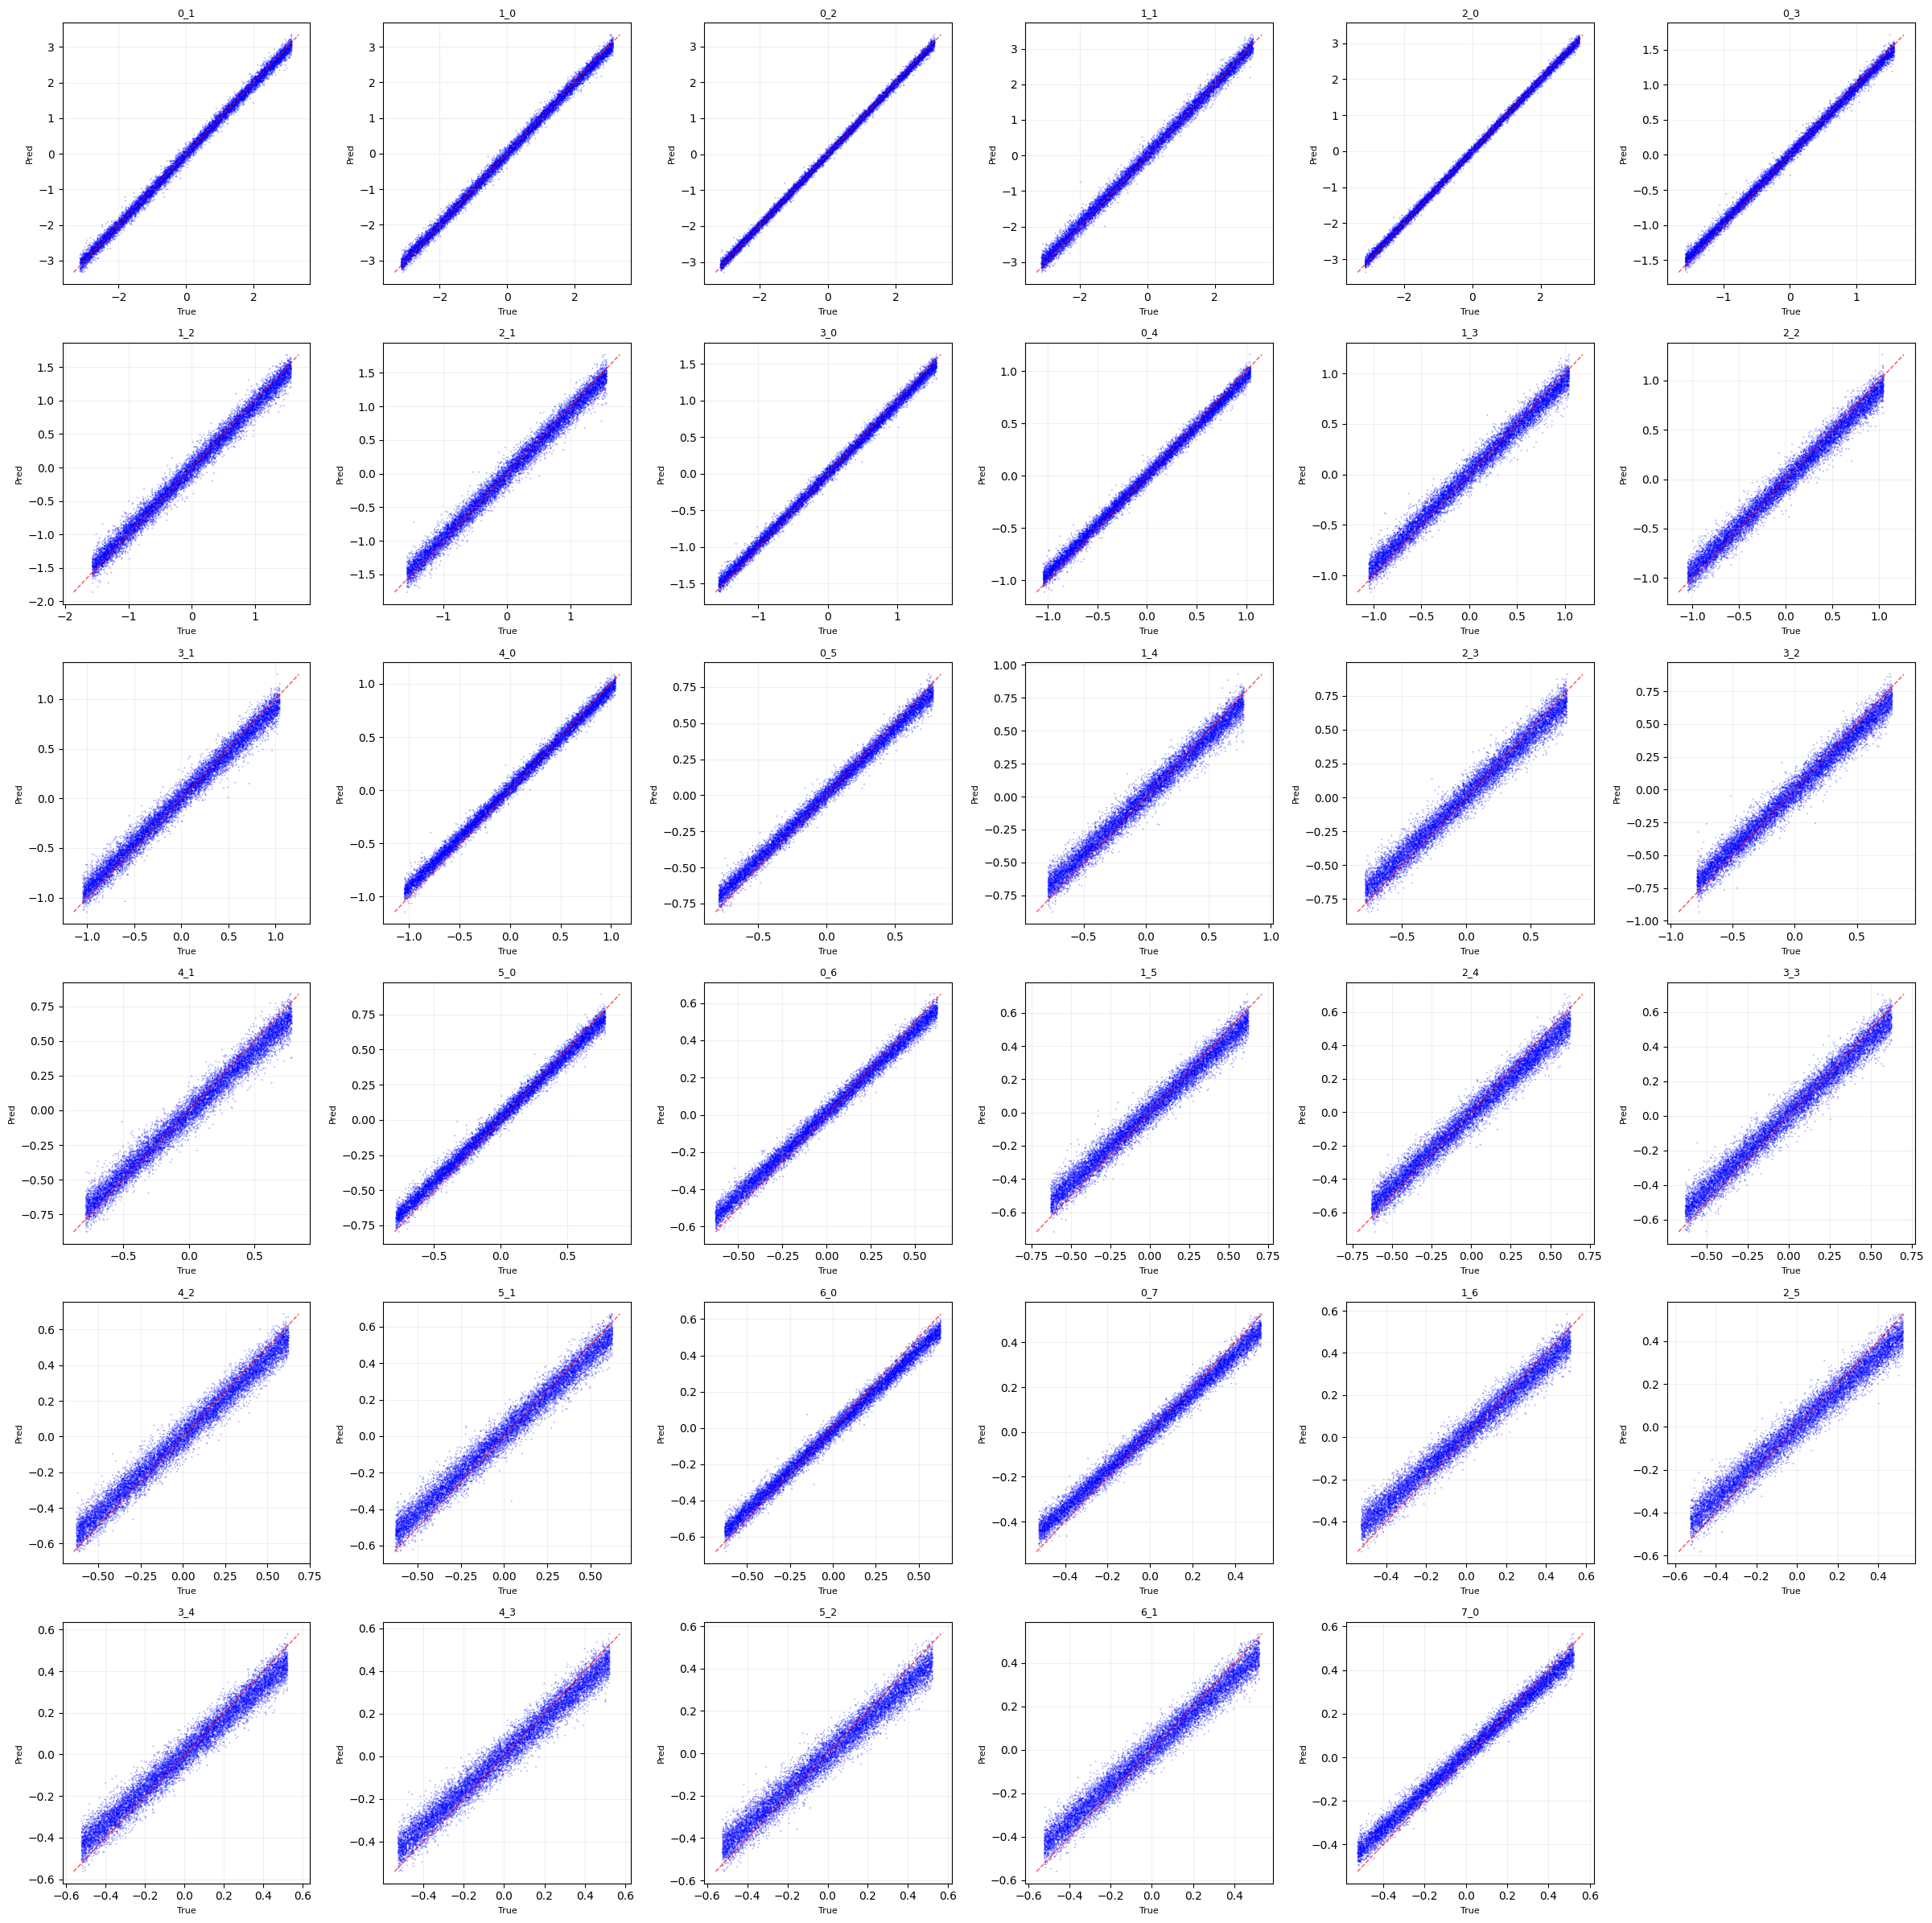

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import torch

#  predictions и targets – массивы numpy (num_samples, 36)
# feature_names – список строк вида "p_q" ( "0_0", "1_0", "0_1", ...)

def plot_chebyshev_predictions(predictions, targets, feature_names, n_cols=6):
    """
    Визуализация предсказаний vs истинных значений для каждого коэффициента Чебышева.
    Все значения нормализованы (делением на π), поэтому отображаются без дополнительного масштабирования.
    """
    n_features = len(feature_names)
    n_rows = (n_features + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
    axes = axes.flatten()

    for i in range(n_features):
        ax = axes[i]
        # Восстанавливаем исходные значения (умножаем на π) для наглядности
        true_vals = targets[:, i] * np.pi
        pred_vals = predictions[:, i] * np.pi

        ax.scatter(true_vals, pred_vals, alpha=0.3, s=2, c='blue', edgecolors='none')

        # Линия идеального предсказания (y = x)
        min_val = min(true_vals.min(), pred_vals.min())
        max_val = max(true_vals.max(), pred_vals.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.7, linewidth=1)

        ax.set_xlabel('True', fontsize=8)
        ax.set_ylabel('Pred', fontsize=8)
        ax.set_title(f'{feature_names[i]}', fontsize=9)
        ax.grid(True, alpha=0.2)

    # Скрываем пустые subplots
    for i in range(n_features, len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.savefig('chebyshev_predictions.png', dpi=200, bbox_inches='tight')
    plt.show()

plot_chebyshev_predictions(predictions, targets, cheb_keys, n_cols=6)

In [20]:
import json
import numpy as np
from PIL import Image
import torch
import os

def predict_single_image_chebyshev(model, image_path, transform, cheb_keys, device, 
                                   decimals=6, include_piston=False, piston_value=0.0):
    """
    Предсказание коэффициентов Чебышева для одного трёхканального изображения 256x256.

    Параметры:
        model          : обученная модель (ChebyshevRegressionModel)
        image_path     : путь к PNG-изображению (3 канала)
        transform      : трансформации (должны включать ToTensor и Normalize)
        cheb_keys      : список ключей коэффициентов в порядке, ожидаемом моделью (без '0_0')
        device         : torch.device
        decimals       : число знаков после запятой в выводе
        include_piston : если True, добавляет ключ '0_0' со значением piston_value
        piston_value   : значение для '0_0' (обычно 0.0)

    Возвращает:
        dict с ключом 'chebyshev_coefficients', где значения — исходные коэффициенты (радианы)
    """
    model.eval()

    # Проверка существования файла
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image file not found: {image_path}")

    # Загрузка и ресайз
    image = Image.open(image_path)
    if image.size != (256, 256):
        image = image.resize((256, 256), Image.LANCZOS)
        print("Изображение изменено до 256x256")

    # Тензор и предсказание
    image_tensor = transform(image).unsqueeze(0).to(device)
    with torch.inference_mode():   # быстрее, чем no_grad()
        pred_normalized = model(image_tensor)   # (1, num_coeffs) – нормализованные делением на π

    # Возврат к исходному масштабу
    pred_original = pred_normalized[0].cpu().numpy() * np.pi

    # Сборка словаря
    coeffs_dict = {}
    for i, key in enumerate(cheb_keys):
        coeffs_dict[key] = round(float(pred_original[i]), decimals)

    # Опционально добавляем 0_0 (piston)
    if include_piston:
        coeffs_dict['0_0'] = round(float(piston_value), decimals)

    return {'chebyshev_coefficients': coeffs_dict}


# Загружаем метаданные (они уже содержат ключи без 0_0)
with open(os.path.join(datasetDirectory, 'metadata.json'), 'r') as f:
    metadata = json.load(f)

sample_keys = list(metadata[0]['chebyshev_coefficients'].keys())
if '0_0' in sample_keys:
    sample_keys.remove('0_0')

def key_order(key):
    p, q = map(int, key.split('_'))
    return (p+q, p, q)

cheb_keys = sorted(sample_keys, key=key_order)   # теперь 35 ключей

# Предсказание без piston (только 35 коэффициентов)
result_no_piston = predict_single_image_chebyshev(
    model,
    'dataset/difracted_beams/difracted_beam_000000.png',
    val_transform,
    cheb_keys,
    device,
    include_piston=False
)
print("Без 0_0:", result_no_piston['chebyshev_coefficients'])

# Предсказание с piston (0_0 = 0)
result_with_piston = predict_single_image_chebyshev(
    model,
    'dataset/difracted_beams/difracted_beam_000000.png',
    val_transform,
    cheb_keys,
    device,
    include_piston=True,
    piston_value=0.0
)
#print("С 0_0 = 0:", result_with_piston['chebyshev_coefficients'])

Без 0_0: {'0_1': 1.373482, '1_0': 0.634768, '0_2': 0.330968, '1_1': -0.281865, '2_0': 1.001752, '0_3': -0.253661, '1_2': 1.203644, '2_1': 1.36365, '3_0': -0.363188, '0_4': 0.645386, '1_3': 0.047414, '2_2': 0.230862, '3_1': 0.824649, '4_0': -0.801961, '0_5': -0.554193, '1_4': -0.68453, '2_3': 0.403654, '3_2': 0.368094, '4_1': 0.477436, '5_0': 0.729887, '0_6': 0.355477, '1_5': -0.057497, '2_4': 0.340947, '3_3': -0.482183, '4_2': 0.128773, '5_1': -0.36809, '6_0': 0.485257, '0_7': -0.037276, '1_6': -0.054734, '2_5': -0.231533, '3_4': 0.219475, '4_3': -0.058811, '5_2': 0.051514, '6_1': -0.431305, '7_0': 0.108444}


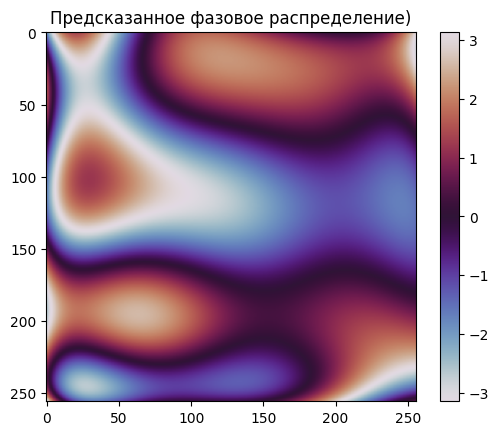

In [28]:
import modulesDataSet as mds
# Загрузка лучшей модели
model.load_state_dict(torch.load('chebyshev_model_best.pth')['model_state_dict'])
model.to(device)
model.eval()

# Предсказание для экспериментального изображения
result = predict_single_image_chebyshev(
    model,
    'dataset/difracted_beams/difracted_beam_000000.png',
    val_transform,
    cheb_keys,
    device,
    include_piston=True
)

coeffs = result['chebyshev_coefficients']  # словарь с коэффициентами (включая 0_0=0)

# Восстановление фазы и генерация корректирующей маски
phase = mds.reconstruct_phase_from_chebyshev(coeffs, size=256)

import matplotlib.pyplot as plt
plt.imshow(phase, cmap='twilight')
plt.colorbar()
plt.title('Предсказанное фазовое распределение)')
plt.show()

correction_mask = 255 - ((phase + np.pi) / (2 * np.pi) * 255).astype(np.uint8)

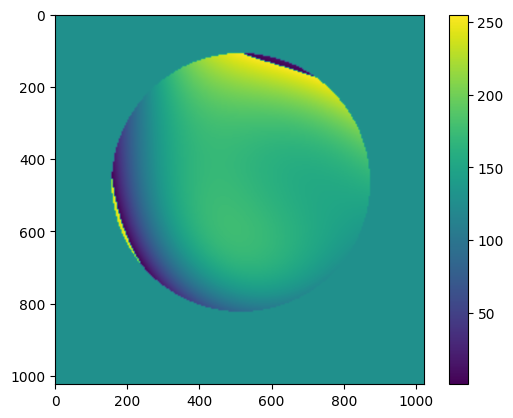

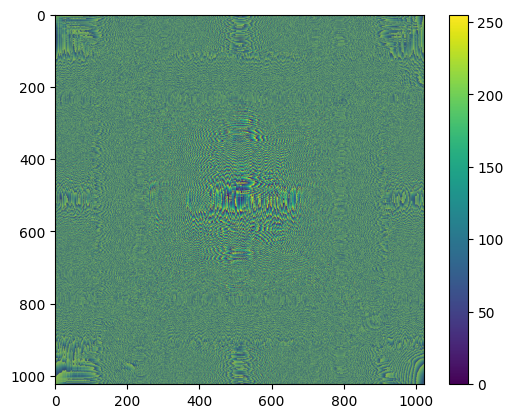

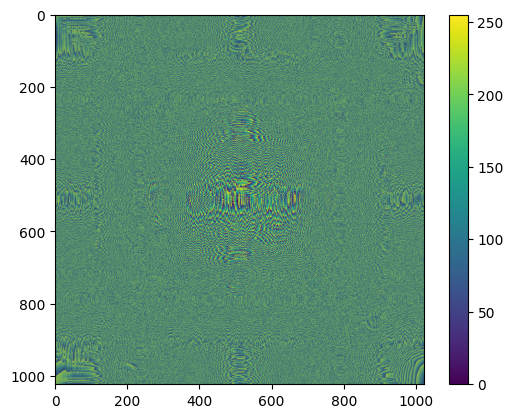

In [33]:
import cv2
hologram = cv2.imread('C:/Users/thatm/VSCodeProjects/experiment/trans.png', cv2.IMREAD_GRAYSCALE)
correction_mask = cv2.resize(correction_mask, (1024, 1024))
corrected_holo = hologram + correction_mask

plt.imshow(correction_mask)
plt.colorbar()
plt.show()

plt.imshow(hologram)
plt.colorbar()
plt.show()
plt.imshow(corrected_holo)
plt.colorbar()
plt.show()

Image.fromarray(corrected_holo).save('C:/Users/thatm/VSCodeProjects/experiment/trans_fixed.png')

In [ ]:
2

NameError: name 'dataset' is not defined